# Expected APY Model

## WR

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [59]:
DATA_PATH = Path('../artifacts/roster_roi_combined.csv')

league_cap_by_year = {
    2023: 224.8,
    2024: 255.4,
    2025: 279.2
}

SEED = 42

df = pd.read_csv(DATA_PATH)
wr_df = df[(df['position'] == 'WR') & (df['snaps'].fillna(0) >= 100)].copy()

In [60]:
wr_df['target_pct'] = wr_df['cap_pct_of_team'].astype(float) * 100.0
wr_df['target_pct'] = wr_df['target_pct'].replace([np.inf, -np.inf], np.nan).fillna(0.0)
wr_df['y_log'] = np.log1p(wr_df['target_pct'])

In [61]:
train_df = wr_df[wr_df['is_rookie_deal'] == False].copy()

features = ['total_epa', 'snaps', 'epa_per_snap']
X_train = train_df[features].fillna(0).astype(float)
y_train_log = train_df['y_log'].values

max_train_epa = X_train['total_epa'].max()
max_train_snaps = X_train['snaps'].max()
max_market_apy = train_df['yearly_cap_hit'].max()

In [62]:
groups = train_df['gsis_id'].values
gkf = GroupKFold(n_splits=5)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=SEED))
])

param_grid = {'ridge__alpha': np.logspace(-3, 3, 50)}

gs = GridSearchCV(
    pipe, 
    param_grid=param_grid, 
    cv=gkf, 
    n_jobs=-1, 
    scoring='neg_root_mean_squared_error'
)
gs.fit(X_train, y_train_log, groups=groups)

best_model = gs.best_estimator_
best_alpha = gs.best_params_['ridge__alpha']

In [63]:
train_preds_log = best_model.predict(X_train)
rmse_log = np.sqrt(mean_squared_error(y_train_log, train_preds_log))

train_preds_pct = np.expm1(train_preds_log)
train_season_caps = train_df['season'].map(league_cap_by_year).ffill()
train_preds_dollars = (train_preds_pct / 100.0) * train_season_caps

mae_dollars = mean_absolute_error(train_df['yearly_cap_hit'], train_preds_dollars)
r2_dollars = r2_score(train_df['yearly_cap_hit'], train_preds_dollars)

print('--- 3-Year Veteran WR Market Model ---')
print(f'Best Ridge Alpha: {best_alpha:.2f}')
print(f'RMSE (log target): {rmse_log:.4f}')
print(f'MAE (Millions): ${mae_dollars:.2f}M')
print(f'R-Squared (Dollars): {r2_dollars:.3f}')

--- 3-Year Veteran WR Market Model ---
Best Ridge Alpha: 14.56
RMSE (log target): 0.6211
MAE (Millions): $5.19M
R-Squared (Dollars): 0.427


In [64]:
X_all = wr_df[features].fillna(0).astype(float)
all_preds_log = best_model.predict(X_all)
all_preds_pct = np.expm1(all_preds_log)

median_cap = np.nanmedian(list(league_cap_by_year.values()))
wr_df['season_cap_m'] = wr_df['season'].map(league_cap_by_year).fillna(median_cap)

raw_expected_dollars = (all_preds_pct / 100.0) * wr_df['season_cap_m']

market_ceiling = max_market_apy * 1.10
wr_df['expected_apy_raw'] = raw_expected_dollars
wr_df['expected_apy'] = np.clip(raw_expected_dollars, a_min=0, a_max=market_ceiling)
wr_df['surplus_value'] = wr_df['expected_apy'] - wr_df['yearly_cap_hit']

wr_df['is_extrapolated'] = (wr_df['total_epa'] > max_train_epa) | (wr_df['snaps'] > max_train_snaps)

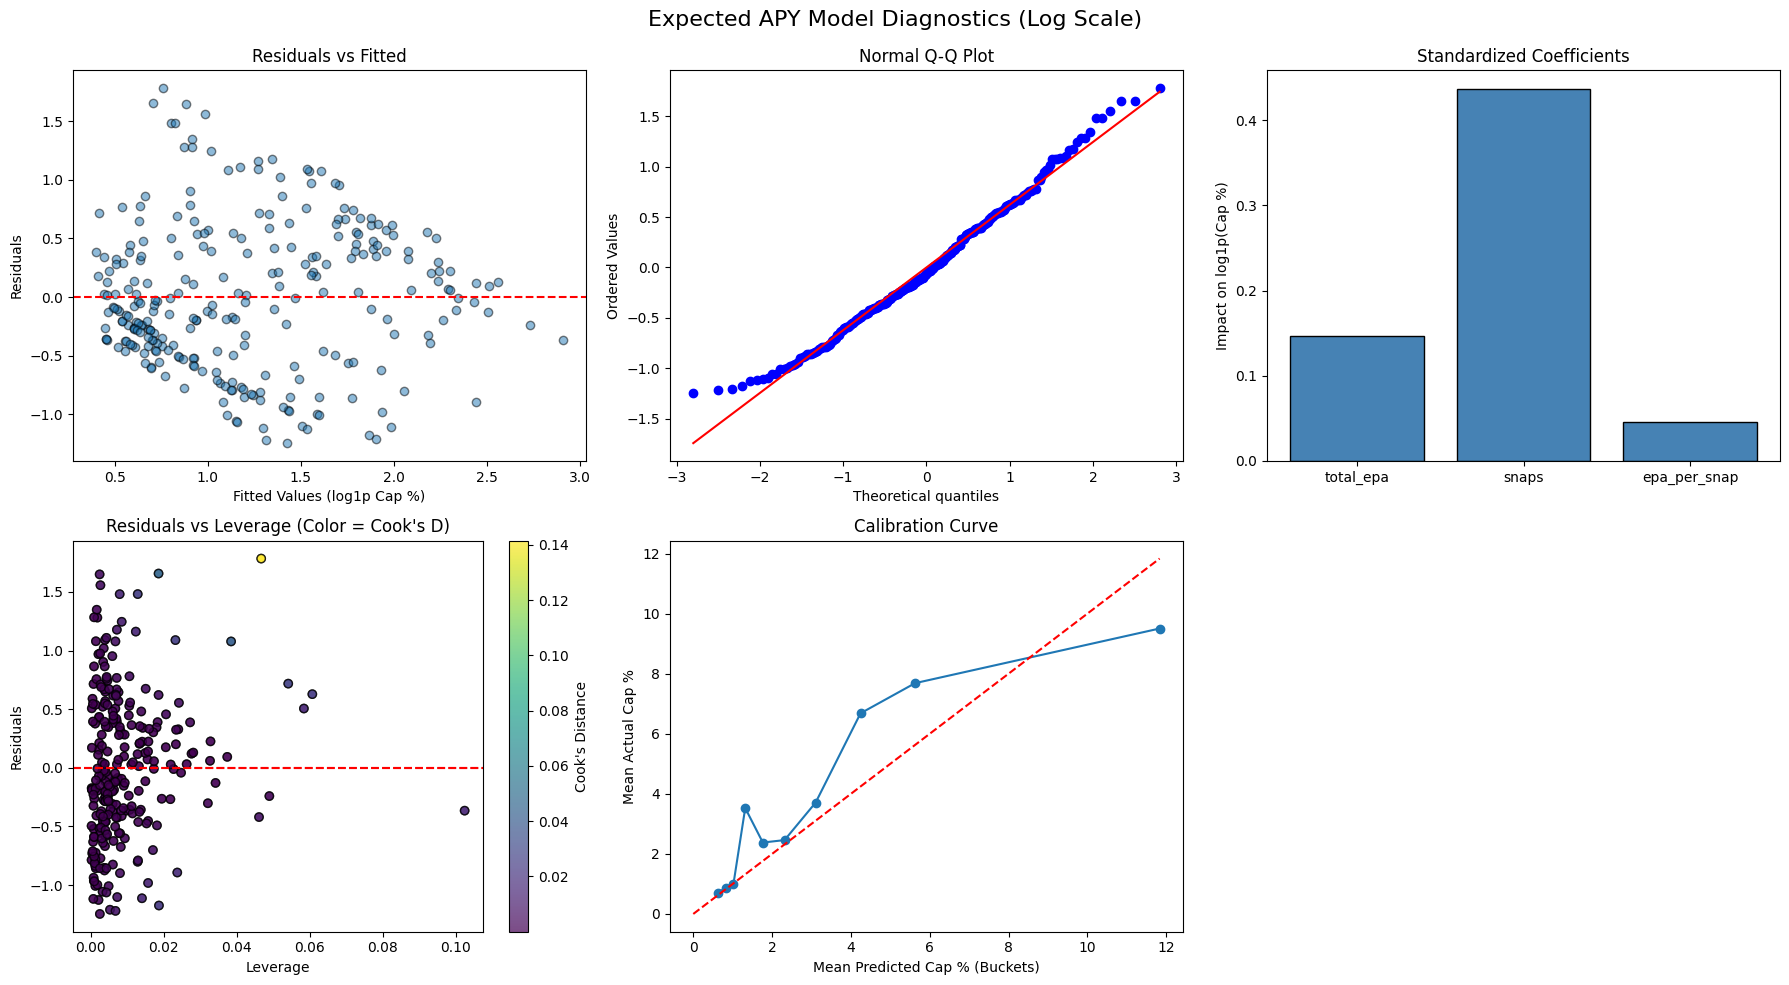


--- TOP 10 WR ARBITRAGE ASSETS (2025) ---
Puka Nacua | Rookie | EPA 120.8 | Snaps 905 | APY actual 1.02M | expected 44.28M [EXTRAPOLATED] | surplus +43.25M
Jaxon Smith-Njigba | Rookie | EPA 84.5 | Snaps 972 | APY actual 3.60M | expected 36.84M  | surplus +33.24M
George Pickens | Rookie | EPA 77.8 | Snaps 968 | APY actual 1.69M | expected 33.87M  | surplus +32.18M
Alec Pierce | Rookie | EPA 48.9 | Snaps 814 | APY actual 1.65M | expected 18.91M  | surplus +17.26M
Romeo Doubs | Rookie | EPA 42.5 | Snaps 832 | APY actual 1.09M | expected 17.91M  | surplus +16.82M
Zay Flowers | Rookie | EPA 44.0 | Snaps 878 | APY actual 3.51M | expected 19.62M  | surplus +16.11M
Michael Wilson | Rookie | EPA 25.4 | Snaps 923 | APY actual 1.33M | expected 16.65M  | surplus +15.31M
Wan'Dale Robinson | Rookie | EPA 22.0 | Snaps 973 | APY actual 2.05M | expected 17.34M  | surplus +15.29M
Tre Tucker | Rookie | EPA 21.8 | Snaps 942 | APY actual 1.33M | expected 16.43M  | surplus +15.10M
Kayshon Boutte | Rookie |

In [65]:
residuals = y_train_log - train_preds_log

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Expected APY Model Diagnostics (Log Scale)', fontsize=16)

# Plot 1: Residuals vs Fitted
axes[0, 0].scatter(train_preds_log, residuals, alpha=0.5, edgecolors='k')
axes[0, 0].axhline(0, color='r', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values (log1p Cap %)')
axes[0, 0].set_ylabel('Residuals')

# Plot 2: QQ Plot
stats.probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot')

# Plot 3: Coefficients (Scaled)
ridge_coefs = best_model.named_steps['ridge'].coef_
axes[0, 2].bar(features, ridge_coefs, color='steelblue', edgecolor='black')
axes[0, 2].set_title('Standardized Coefficients')
axes[0, 2].set_ylabel('Impact on log1p(Cap %)')

# Plot 4: Leverage vs Residuals (Approximate Cook's D)
X_scaled = best_model.named_steps['scaler'].transform(X_train)
H = X_scaled @ np.linalg.inv(X_scaled.T @ X_scaled + best_alpha * np.eye(X_scaled.shape[1])) @ X_scaled.T
leverage = np.diagonal(H)
mse = np.mean(residuals**2)
p = X_train.shape[1]
cooks_d = (residuals**2 / (p * mse)) * (leverage / (1 - leverage)**2)

scatter = axes[1, 0].scatter(leverage, residuals, c=cooks_d, cmap='viridis', alpha=0.7, edgecolors='k')
axes[1, 0].axhline(0, color='r', linestyle='--')
scatter = axes[1, 0].scatter(leverage, residuals, c=cooks_d, cmap='viridis', alpha=0.7, edgecolors='k')
axes[1, 0].axhline(0, color='r', linestyle='--')
axes[1, 0].set_title("Residuals vs Leverage (Color = Cook\'s D)")
axes[1, 0].set_xlabel('Leverage')
axes[1, 0].set_ylabel('Residuals')
plt.colorbar(scatter, ax=axes[1, 0], label="Cook\'s Distance")

# Plot 5: Calibration Plot
train_df['pred_pct_bin'] = pd.qcut(train_preds_pct, q=10, duplicates='drop')
calibration_df = train_df.groupby('pred_pct_bin', observed=True)[['target_pct']].mean()
calibration_df['mean_pred_pct'] = train_df.groupby('pred_pct_bin', observed=True)['target_pct'].transform('mean') # using transform to align sizes for plotting

mean_pred_buckets = [b.mid for b in calibration_df.index]
mean_actual_buckets = calibration_df['target_pct'].values

axes[1, 1].plot(mean_pred_buckets, mean_actual_buckets, marker='o', linestyle='-')
axes[1, 1].plot([0, max(mean_pred_buckets)], [0, max(mean_pred_buckets)], color='r', linestyle='--')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].set_xlabel('Mean Predicted Cap % (Buckets)')
axes[1, 1].set_ylabel('Mean Actual Cap %')

# Hide empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Print Top Output
top_2025 = wr_df[wr_df['season'] == 2025].sort_values('surplus_value', ascending=False).head(10)
print('\n--- TOP 10 WR ARBITRAGE ASSETS (2025) ---')
for _, r in top_2025.iterrows():
    cohort = 'Rookie' if r['is_rookie_deal'] else 'Veteran'
    extrap = '[EXTRAPOLATED]' if r['is_extrapolated'] else ''
    print(f"{r['player_name']} | {cohort} | EPA {r['total_epa']:.1f} | Snaps {int(r['snaps'])} | APY actual {r['yearly_cap_hit']:.2f}M | expected {r['expected_apy']:.2f}M {extrap} | surplus +{r['surplus_value']:.2f}M")